In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_percentage_error, mean_absolute_error
from scipy.optimize import curve_fit

sns.set_style()
sns.set_theme()

In [4]:
df = pd.read_excel('./././data/waste_water/all_actual_data.xlsx')
seconds = np.array(df['min'])*60
df['hours'] = df['min']/60
REAL = np.array(df.iloc[1511, 2:-1]).transpose()
df.head()

,min,day,A0('11-25'),A0('9-16' ),A0('9-10'),A0('9-20'),A0('9-24'),A0('9-27'),A0('9-11'),A0('11-28'),...,D('10-28'),D('10-21'),D('11-13'),D('10-24'),D('10-30'),A('9-30'),B('9-30'),C('9-30'),D('9-30'),hours
0,0.0,0.000000,0.0073,0.0000,0.0061,0.0032,0.0107,0.0136,0.0142,0.0061,...,0.0001,0.0014,0.0020,0.0007,0.0002,0.0286,0.0154,0.0086,0.0209,0.000000
1,5.0,0.003472,0.0394,0.0709,0.0035,0.0029,0.0432,0.0332,0.0124,0.0021,...,0.0007,0.0005,0.0028,0.0008,0.0252,0.0327,0.0229,0.0161,0.0195,0.083333
2,10.0,0.006944,0.0744,0.1349,0.0092,0.0099,0.0819,0.0513,0.0044,0.0036,...,0.0000,0.0006,0.0070,0.0013,0.0039,0.0352,0.0271,0.0211,0.0277,0.166667
3,15.0,0.010417,0.0727,0.1605,0.0179,0.0243,0.1011,0.0599,0.0044,0.0075,...,0.0005,0.0007,0.0142,0.0020,0.0029,0.0372,0.0293,0.0251,0.0361,0.250000
4,20.0,0.013889,0.0685,0.1656,0.0416,0.0458,0.1104,0.0649,0.0047,0.0133,...,0.0007,0.0008,0.0264,0.0031,0.0030,0.0386,0.0318,0.0285,0.0440,0.333333


In [5]:
# Linear BOI and Q
def D(Q):
  x = (Q - 2.7764)/7.9688
  return x

def D0(Q):
  x = (Q - 22.355)/10.93
  return x

def A0(Q):
  x = (Q + 39.478)/9.862
  return x

def A(Q):
  x = (Q + 16.548)/7.9411
  return x

def B0(Q):
  x = (Q + 41.036)/9.9758
  return x

def B(Q):
  x = (Q + 10.56)/7.9659
  return x

def C0(Q):
  x = (Q + 30.168)/8.7912
  return x

def C(Q):
  x = (Q + 18.662)/7.3071
  return x


def renorm(_data, _max, _min):
  return _data*(_max-_min)+_min

def Renormalize(_data, _max, _min):
  renormalize_data = pd.DataFrame()
  for i in range(0, _data.shape[1]-1):
    renormalize_data[_data.columns[i+1]] = renorm(_data.iloc[:, i+1], _max[i], _min[i])
  return renormalize_data


def norm(_data):
    return (_data-_data[1:].min())/(_data.max()-_data[1:].min())



def left_rect(x, f):
  _charge = []
  sum_charge = 0
  h = x[1]-x[0]

  for i in range(0, f.shape[0]):
    sum_charge += h*f[i]
    _charge.append(sum_charge)
  return _charge


def dynamic_function_call(prefix, value):
    """Динамически вызывает функцию по названию префикса."""
    function_name = prefix.strip()
    if function_name in globals():
        return globals()[function_name](value)
    else:
        raise ValueError(f"Функция {function_name} не найдена.")

def BOI(_charge):
    results = []
    for col in _charge.columns:
        prefix = col.split('(')[0]
        values = _charge[col].dropna().values
        if len(values) > 0:
            result = dynamic_function_call(prefix, values[-1])
            results.append(result)
    return results

def percentage_estimate(real_boi, pred_boi):
  _mape = []
  for i in range(0, len(pred_boi)):
    _mape.append(mean_absolute_percentage_error([real_boi[i]], [pred_boi[i]]))
  return _mape

def charge(_x, _data):
  _charge = pd.DataFrame()
  _charge['long'] = pd.Series([i for i in range(1511)])
  for i in range(_data.shape[1]):
    q = left_rect(_x, _data.iloc[:, i].values[:np.count_nonzero(~np.isnan(_data.iloc[:, i].values))]/100)
    _charge[_data.columns[i]] = q + [None] * (1511 - len(q))

  _charge.drop('long', axis=1, inplace=True)
  return _charge

def Normalize(k, _data, _max_index):
  normalize_data = pd.DataFrame()
  normalize_data['long'] = pd.Series([i for i in range(1511)])
  for i in range(_data.shape[1]):
    normalize_data[_data.columns[i]] = norm(_data.iloc[1:k[i], i])

  max_values = []
  min_values = []

  for i in range(_data.shape[1]):
    max_values.append(_data.iloc[_max_index[i], i])
    min_values.append(_data.iloc[1:k[i], i].min())
  normalize_data.drop('long', axis=1, inplace=True)
  normalize_data.drop(normalize_data.index[0], axis=0, inplace=True)

  return (normalize_data, max_values, min_values)

In [6]:
choice_data = df.iloc[:-1, 2:-1]
choice_data = choice_data.iloc[:, np.r_[27:57, 66:76]]
REAL = REAL[np.r_[27:57, 66:76]]

In [7]:
def find_indices_multiple_columns(db, initial_points=12, total_points=289):
    results = {}

    for column in db.columns:
        current_index = 12
        indices = []
        initial_points=12
        total_points=289

        while (current_index < len(db)) and (len(indices) < total_points):
            end_index = current_index + initial_points

            if end_index > len(db):
                break

            points = db[column][current_index:end_index]

            derivative = np.diff(points)
            mean_derivative = np.mean(derivative)


            if mean_derivative < 0:
                indices.append(end_index)
                break
            else:
                current_index += 4

            if initial_points > 260:
                indices.append(144)
                break
        if not indices:
            indices.append(144)
        results[column] = indices

    return results

result_indices = find_indices_multiple_columns(choice_data.iloc[:289, :])

In [8]:
idp = np.squeeze(list(result_indices.values()))
maxes = np.array([choice_data.iloc[:idp[i], i].idxmax() for i in range(choice_data.shape[1])])

In [9]:
max1 = maxes

In [10]:
from sklearn.preprocessing import MinMaxScaler

normalized_data = choice_data.copy()

scaler = MinMaxScaler()

DataAll, MaxAll, MinAll = pd.DataFrame(
    scaler.fit_transform(choice_data),
    columns=choice_data.columns,
    index=choice_data.index
), scaler.data_max_, scaler.data_min_ 

`Кусочная аппроксимация`

In [11]:
from my_package.data_structurs import *
from my_package.approximation import *
from my_package.utils import PipelineLoader

In [12]:
def model_for_synthesis(x, sigma1, mu1, lambda1, sigma2, mu2, lambda2):
    lognormal_part = lambda1 * (np.exp(-((np.log(x) - mu1)**2) / (2 * sigma1**2)) / (x * sigma1 * np.sqrt(2 * np.pi)))
    normal_part = lambda2 * (np.exp(-((x - mu2)**2) / (2 * sigma2**2)) / (sigma2 * np.sqrt(2 * np.pi)))
    return lognormal_part + normal_part

def run_pipeline(pipeline_loader:PipelineLoader):
    result = []
    for func, mapping, parametres, bounds in pipeline_loader:
        approx = search_most_viable_parametres(func, mapping, parametres, bounds, False)
        
        result.append(approx)

    return result

def get_parametres_from_pipeline(results_approx:list):
    results_parametres = pd.DataFrame()
    for res in results_approx:
        local_params = res.parametres_show()
        results_parametres = pd.concat([results_parametres, local_params], ignore_index=True)

    return results_parametres

def get_values_piecewise_approximation(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.y_approx]

    return all_values

def piecewise_func(x, results_approx:list):
    y = np.array([])
    for res in results_approx:
        y = np.r_[y, res.func(x, *res.params)]

    return y

In [18]:
def coeff_search(_data, _right, _left):
    approximate = pd.DataFrame()
    coeff = pd.DataFrame()
    approximate['long'] = df.iloc[1:-1, 1]
    
    for i in range(0, _data.shape[1]):

        param = (1.5, np.log(df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].iloc[-1]), 0.5, 0.5, df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].iloc[-1], 0.5)
        lst1 = [0.05, -5, 0.05, 0.05, 0.05, 0.05]
        lst2 = [3.5, np.log(df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].iloc[-1]), 3, 3, df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].iloc[-1], 1.5]

        independent_vals_count = df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].to_numpy().shape[0]
        independent_vals = df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].to_numpy()

        pipeline_change = StructurePipelineApproximation(
            ['model_for_synthesis_segm1', 'model_for_synthesis_segm2'],
            [model_for_synthesis, model_for_synthesis],
            [[0, independent_vals[independent_vals_count//2]], [independent_vals[independent_vals_count//2], 7]],
            [param, param],
            [(lst1, lst2), (lst1, lst2)]
        )

        now_mapping = Mapping(
            df.iloc[_left[i]+1:_data.iloc[:_right[i], i].count()+1, 1].to_numpy(),
            _data.iloc[_left[i]:_data.iloc[:_right[i], i].count(), i].to_numpy(),
            False
        )

        pipeline = PipelineLoader(now_mapping, pipeline_change)

        all_result = run_pipeline(pipeline)

        coeff = pd.concat([coeff, get_parametres_from_pipeline(all_result)])

        approximate_new_size = np.r_[get_values_piecewise_approximation(all_result), np.zeros(1510 - df.iloc[1:_data.iloc[:-1, i].count()+1, 1].to_numpy().shape[0])]

        approximate[_data.columns[i]] = approximate_new_size
    
    return approximate, coeff

_approxAll, coeffAll = coeff_search(DataAll, [-1 for i in range(DataAll.shape[1])], np.zeros(DataAll.shape[1]).astype(int))
_approxAll.drop('long', axis=1, inplace=True)
# approxAll = Renormalize(_approxAll, MaxAll, MinAll)
approxAll  = pd.DataFrame(
    scaler.inverse_transform(_approxAll),
    columns=_approxAll.columns,
    index=_approxAll.index
)
approx_data = approxAll.copy()
# approxAll[approxAll < 0] = 0

# coeffAll.loc[len(coeffAll)] = MaxAll
# coeffAll.loc[len(coeffAll)] = MinAll
# coeffAll.loc[len(coeffAll)] = choice_data.count()

# cof = coeffAll.T
# cof.columns = ['sigma', 'mu', 'lambda1', 'sigma2', 'mu2', 'lambda2', 'max', 'min', 'len']

# from scipy import integrate
# cof['integral'] = approxAll.fillna(0).apply(lambda col: integrate.simpson(col, x=approxAll.index))

# cof['cluster'] = [0 if col[1] == '0' else 1 for col in choice_data.columns]
# cof['BOD'] = REAL

In [15]:
np.set_printoptions(suppress=True) 
np.set_printoptions(precision=4)    

In [20]:
coeffAll

,sigma1,mu1,lambda1,sigma2,mu2,lambda2
0,0.775393,-1.686521,0.256030,3.000000,0.548611,0.050000
1,0.530352,-1.507905,0.065942,0.584697,0.050000,0.549772
0,0.685110,-1.926805,0.182508,0.140022,0.338877,0.137831
1,0.856704,-0.865527,0.320503,0.656958,0.809028,0.196146
0,1.708498,0.778368,2.164500,0.435950,0.971486,0.050000
...,...,...,...,...,...,...
1,0.531420,0.551275,0.753009,0.979341,3.533346,0.151993
0,1.188515,0.329392,2.102080,3.000000,2.576389,0.050000
1,0.494564,0.087234,0.808748,3.000000,2.576389,0.285693
0,1.248520,0.130953,1.549963,0.674344,1.427249,0.626397


C:\Users\obyde\AppData\Local\Temp\ipykernel_34380\1438501191.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend()


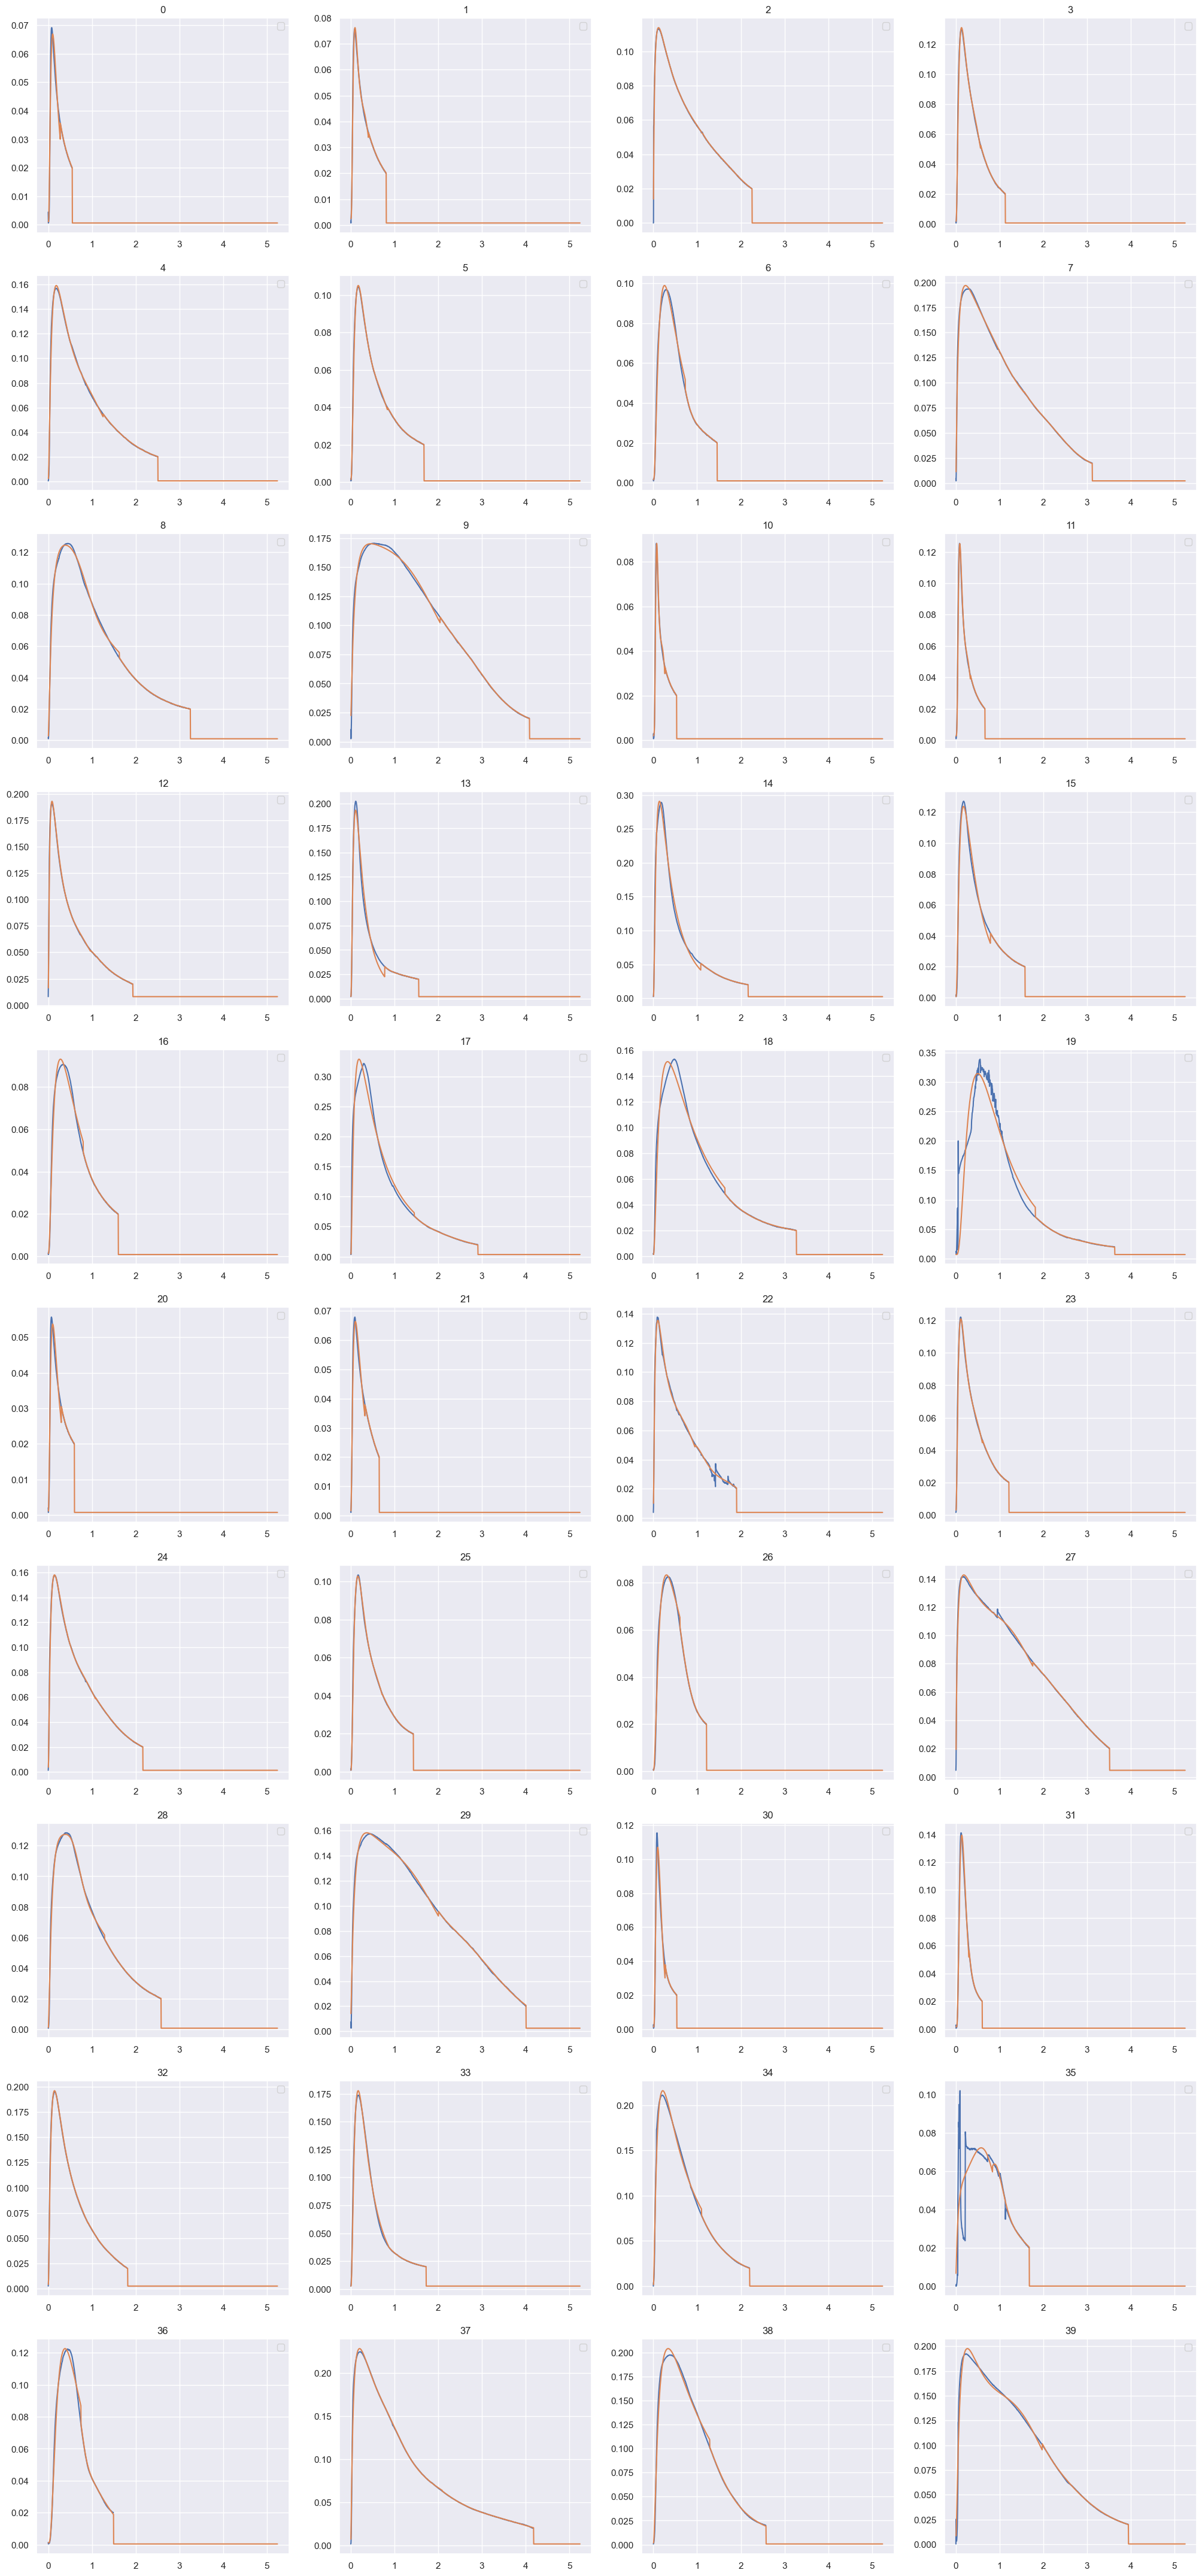

In [16]:
fig, ax = plt.subplots(10, 4, figsize=(25, 55))
axs = [ax[i, j] for i in range(10) for j in range(4)]
for i in range(0, 40):
    axs[i].plot(df.iloc[:1511, 1], choice_data.iloc[:1511, i])
    axs[i].plot(df.iloc[1:approxAll.iloc[:, i].size+1, 1], approxAll.iloc[:, i])
    axs[i].set_title(str(i))
    axs[i].legend()

In [ ]:
# другая функция
def extrapolate_model(x, sigma, mu, a, b):
  return (np.exp(-((np.log(x) - mu)**2) / (2 * sigma**2)) / (x * sigma * np.sqrt(2 * np.pi))) - a/(b + x**2)

def defining_parameters(x, _data, param, _lower_bounds, _upper_bounds):
    try:
        popt, pcov = curve_fit(extrapolate_model, _data, x, param, bounds=(_lower_bounds, _upper_bounds), method='trf')
        return popt
    except Exception as e:
        print(f"Ошибка при выполнении curve_fit: {e}. Используем параметры по умолчанию.")
        return (1.5, 0.5, 0.1, 0.5)

def approximation_and_extrapolation(_data, right, left, cluster):
  approximate = pd.DataFrame()
  coeff = pd.DataFrame()
  approximate['long'] = df.iloc[1:-1, 1]
  for i in range(0, _data.shape[1]):
    param = (1.5, 0.5, 0.1, 0.5)
    lower_bounds, upper_bounds = [0, -1.5, -1.5, 0.05], [1.9, 0.55, 0.15, 1.2]
    sigma, mu, a, b = defining_parameters(_data.iloc[left[i]:_data.iloc[:right[i], i].count(), i], df.iloc[left[i]+1:_data.iloc[:right[i], i].count()+1, 1], param, lower_bounds, upper_bounds)
    coeff[_data.columns[i]] = sigma, mu, a, b
    approximate[_data.columns[i]] = extrapolate_model(df.iloc[1:1300, 1], sigma, mu, a, b)
  return approximate, coeff